# Taller 1: Econometría

- **Profesor:** Francisco Alfaro Medina
- **Ayudantes:** Krischnna Cortez y Karen Rojas


### Instrucciones

- Dispone de **60 minutos** para completar los **100 puntos** del taller.
- Cuide la presentación y redacción de sus respuestas.
- Puede utilizar su computador y los apuntes de clase y ayudantía.
- Debe entregar un archivo **PDF** y un **R script** (extensión `.R`).

> ⚠️ **Importante para Colab:** Este notebook usa un kernel de R. Si abre este archivo en Google Colab, seleccione **Runtime → Change runtime type → R** antes de ejecutar cualquier celda.

---
# Sección 1: Datos Aleatorios *(30 puntos)*

En esta sección trabajaremos con un dataset **simulado** de 50 alumnos de la USM. El dataset contiene las siguientes variables:

| Variable | Descripción |
|---|---|
| `hrs_sueno` | Horas de sueño promedio en el último mes |
| `profesor_part` | Si recibió ayuda de profesor particular (0/1) |
| `media_sem_pasado` | Promedio de notas del semestre anterior |
| `tiempo_est` | Horas de estudio dedicadas |
| `asistencia` | Porcentaje de asistencia a clases |
| `nivel_socioec` | Nivel socioeconómico (1 al 5) |
| `notas` | **Variable dependiente** — nota del alumno |

## Pregunta 1.1 — Generar el dataset *(6 pts.)*

Antes de ejecutar el código, **cambie la semilla** según la primera letra de su apellido:

| A–E | F–J | K–O | P–T | U–Z |
|:---:|:---:|:---:|:---:|:---:|
| 123 | 456 | 789 | 101112 | 131415 |

Reemplace el valor en `set.seed(...)` antes de continuar.

In [1]:
# -------------------------------------------------------
# Pregunta 1.1: Generar el dataframe "datos"
# Cambie la semilla según la primera letra de su apellido
# A-E: 123 | F-J: 456 | K-O: 789 | P-T: 101112 | U-Z: 131415
# -------------------------------------------------------

set.seed(456)  # <-- CAMBIE ESTE VALOR SEGÚN SU APELLIDO

datos <- data.frame(
  hrs_sueno        = round(runif(50, min = 5,  max = 10),  1),
  profesor_part    = sample(c(0, 1), 50, replace = TRUE),
  media_sem_pasado = round(runif(50, min = 60, max = 100), 1),
  tiempo_est       = round(runif(50, min = 1,  max = 8),   1),
  asistencia       = round(runif(50, min = 60, max = 100), 1),
  nivel_socioec    = sample(1:5, 50, replace = TRUE)
)

# Calcular notas con ponderaciones definidas
datos$notas <- 30 +
  datos$hrs_sueno        * 1.5  +
  datos$profesor_part    * 3    +
  datos$media_sem_pasado * 0.2  +
  datos$tiempo_est       * 2    +
  datos$asistencia       * 0.15 +
  datos$nivel_socioec    * 2    +
  rnorm(50, mean = 0, sd = 5)

# Asegurar rango entre 20 y 100
datos$notas <- pmax(pmin(datos$notas, 100), 20)

# Vista rápida del dataset
cat("Dimensiones del dataset:", nrow(datos), "filas x", ncol(datos), "columnas\n")
head(datos)

Dimensiones del dataset: 50 filas x 7 columnas


,hrs_sueno,profesor_part,media_sem_pasado,tiempo_est,asistencia,nivel_socioec,notas
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
1,5.4,1,70.1,5.2,81.9,1,83.21864
2,6.1,0,65.4,7.6,87.2,2,78.83220
3,8.7,1,76.0,4.2,92.3,1,94.35772
4,9.3,0,71.3,1.9,62.6,4,78.93037
5,8.9,0,90.1,2.4,78.5,1,68.33906
6,6.7,1,92.2,7.9,67.2,2,92.12520


## Pregunta 1.2 — Redondear notas *(2 pts.)*

Redondee la variable `notas` a **1 decimal**.

In [2]:
# Pregunta 1.2: Redondear notas a 1 decimal

datos$notas <- round(datos$notas, 1)
head(datos)

,hrs_sueno,profesor_part,media_sem_pasado,tiempo_est,asistencia,nivel_socioec,notas
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
1,5.4,1,70.1,5.2,81.9,1,83.2
2,6.1,0,65.4,7.6,87.2,2,78.8
3,8.7,1,76.0,4.2,92.3,1,94.4
4,9.3,0,71.3,1.9,62.6,4,78.9
5,8.9,0,90.1,2.4,78.5,1,68.3
6,6.7,1,92.2,7.9,67.2,2,92.1


## Pregunta 1.3 — Estimadores β via álgebra matricial *(8 pts.)*

Calcule los estimadores MCO **manualmente**, usando la fórmula matricial:

$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$

**Sin usar** la función `lm()` de R.

In [3]:
# Pregunta 1.3: Estimadores beta via álgebra matricial (sin lm)

Y <- as.matrix(datos$notas)

X <- as.matrix(cbind(
  1,
  datos$hrs_sueno,
  datos$profesor_part,
  datos$media_sem_pasado,
  datos$tiempo_est,
  datos$asistencia,
  datos$nivel_socioec
))

beta_hat <- solve(t(X) %*% X) %*% t(X) %*% Y
beta_hat

37.5650331
1.1890714
3.3931207
0.1540009
2.0868141
0.1479018
1.2941671


In [4]:
rownames(beta_hat) <- c(
  "Intercepto",
  "hrs_sueno",
  "profesor_part",
  "media_sem_pasado",
  "tiempo_est",
  "asistencia",
  "nivel_socioec"
)

beta_hat

Intercepto,37.5650331
hrs_sueno,1.1890714
profesor_part,3.3931207
media_sem_pasado,0.1540009
tiempo_est,2.0868141
asistencia,0.1479018
nivel_socioec,1.2941671


Se calcularon los estimadores MCO **manualmente**, usando la fórmula matricial:

$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$

**Sin usar** la función `lm()` de R.

## Pregunta 1.4 — Modelo con `lm()` e interpretación *(8 pts.)*

Genere el modelo de regresión múltiple usando la función `lm()` y obtenga el resumen con `summary()`.  
Luego, **interprete cada coeficiente** en el espacio indicado.

> 💡 **Tip:** Los β de `lm()` deben coincidir con los calculados manualmente en la pregunta anterior.

In [5]:
# Pregunta 1.4: Modelo con lm() y summary
modelo_datos <- lm(
  notas ~ hrs_sueno + profesor_part + media_sem_pasado +
    tiempo_est + asistencia + nivel_socioec,
  data = datos
)

summary(modelo_datos)


Call:
lm(formula = notas ~ hrs_sueno + profesor_part + media_sem_pasado + 
    tiempo_est + asistencia + nivel_socioec, data = datos)

Residuals:
     Min       1Q   Median       3Q      Max 
-11.6361  -2.7810   0.7679   3.2845   7.7196 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)      37.56503    7.29826   5.147 6.24e-06 ***
hrs_sueno         1.18907    0.46762   2.543   0.0147 *  
profesor_part     3.39312    1.35962   2.496   0.0165 *  
media_sem_pasado  0.15400    0.06043   2.549   0.0145 *  
tiempo_est        2.08681    0.34870   5.985 3.85e-07 ***
asistencia        0.14790    0.05836   2.534   0.0150 *  
nivel_socioec     1.29417    0.48487   2.669   0.0107 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.726 on 43 degrees of freedom
Multiple R-squared:  0.6123,	Adjusted R-squared:  0.5582 
F-statistic: 11.32 on 6 and 43 DF,  p-value: 1.491e-07


*La interpretación de cada uno de los coeficientes es la siguiente:*

**hrs_sueno:** cambio en la nota por una hora adicional de sueño

**profesor_part:** diferencia en nota entre tener y no tener profesor particular.

**media_sem_pasado:** cambio en nota por un punto adicional en el promedio anterior.

**tiempo_est:** cambio en nota por una hora más de estudio.

**asistencia:** cambio en nota por un punto porcentual más de asistencia.

**nivel_socioec:** cambio en nota por subir un nivel socioeconómico.

## Pregunta 1.5 — Relación entre betas y ponderaciones del código *(6 pts.)*

Analice la relación entre los coeficientes estimados (β̂) y las ponderaciones reales usadas en el código del Anexo para generar las notas.



In [ ]:
# Pregunta 1.5: Comparación entre betas estimados y ponderaciones reales

Debido a la presencia del error aleatorio, al estimar la regrasión con lm() se obtienen coeficientes estimados que son cercanos que son cercanos a los valores reales pero que no son exactamente iguales. Dado que los parametros fueron fijados previamente en el código. Los betas estimados deberían ser cercanos a las ponderaciones utilizadas.


# Sección 2: Wooldridge *(70 puntos)*

Para esta sección utilizaremos el paquete `wooldridge`, que contiene bases de datos clásicas de econometría.

In [6]:
# Instalar y cargar el paquete wooldridge (solo necesario la primera vez en Colab)
if (!require(wooldridge)) install.packages("wooldridge")
library(wooldridge)

Loading required package: wooldridge

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘wooldridge’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



---
## 2A. Base `wage1` *(30 puntos)*

El modelo de regresión poblacional a estimar es:

$$wage = \beta_0 + \beta_1\, educ + \beta_2\, exper + \beta_3\, tenure + u$$

Donde:
- `wage` = salario por hora (USD)
- `educ` = años de escolaridad
- `exper` = años de experiencia laboral
- `tenure` = años en el trabajo actual

In [7]:
# Cargar y limpiar la base wage1
data("wage1")
wage1 <- na.omit(wage1)

### Pregunta 2A.1 — Estimadores MCO e interpretación *(8 pts.)*

Estime el modelo completo e interprete los resultados.

In [8]:
# Pregunta 2A.1: Modelo de regresión múltiple con wage1

library(wooldridge)

data("wage1")

modelo_wage <- lm(wage ~ educ + exper + tenure, data = wage1)
summary(modelo_wage)


Call:
lm(formula = wage ~ educ + exper + tenure, data = wage1)

Residuals:
    Min      1Q  Median      3Q     Max 
-7.6068 -1.7747 -0.6279  1.1969 14.6536 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -2.87273    0.72896  -3.941 9.22e-05 ***
educ         0.59897    0.05128  11.679  < 2e-16 ***
exper        0.02234    0.01206   1.853   0.0645 .  
tenure       0.16927    0.02164   7.820 2.93e-14 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.084 on 522 degrees of freedom
Multiple R-squared:  0.3064,	Adjusted R-squared:  0.3024 
F-statistic: 76.87 on 3 and 522 DF,  p-value: < 2.2e-16


**Interpretación resultados**

Considerando constantes las variables:

- El intercepto representa el salario esperado cuando todas las variables explicativas tienen valor = 0.

- 1 año adicional de educación, aumenta el salario en aproximadamente 0.59897 unidades

- 1 año adicional de experiencia laboral, aumenta el salario en 0.02234 unidades.

- 1 año adicional de actividad en el trabajo, aumenta el salario en 0.16927 unidades.

Considerando el R^2 0.3064, indica que aproximadamente un 30.64 % de la variación del salario es explicada por la educación, la experiencia y la antigüedad laboral.

El R^2 ajustado es 0.3024, que es muy cercano al R^2, lo que implica que no existe una pérdida relevante por incluir regresores poco relevantes.

### Pregunta 2A.2 — ¿Los signos son los esperados? *(10 pts.)*

Antes de ver los resultados, reflexione: ¿qué signo debería tener cada coeficiente económicamente?

In [ ]:
# Pregunta 2A.2: Revisar signos de los coeficientes

Los signos sí son los esperados. Deben tener signo positivo, lo que significa que más educación, más experiencia laboral y mayor tiempo en la misma empresa implica mayor salario.

### Pregunta 2A.3 — Comparar R² y R² ajustado *(12 pts.)*

Estime un segundo modelo usando solo `educ` y `tenure`, y compare el ajuste con el modelo completo.

In [9]:
# Pregunta 2A.3: Modelo reducido (sin exper)

modelo_wage_reducido <- lm(wage ~ educ + tenure, data = wage1)

summary(modelo_wage)$r.squared
summary(modelo_wage)$adj.r.squared

summary(modelo_wage_reducido)$r.squared
summary(modelo_wage_reducido)$adj.r.squared

[1] 0.3064224

[1] 0.3024364

[1] 0.301861

[1] 0.2991912

Al eliminar exper, tanto el R^2 como el R^2 ajustado disminuyen pero levemente. Esto se podría explicar porque exper aporta algo de capacidad explicativa, pero su contribución es pequeña. Como la diferencia entre ambos modelos es reducida, se puede concluir que el modelo con solo educ y tenure conserva gran parte del poder explicativo del modelo completo.

---
## 2B. Base `attend` *(40 puntos)*

En esta sección analizamos los determinantes del rendimiento en el examen final de un curso universitario.

### Pregunta 2B.1 — Cargar la base `attend` *(4 pts.)*

In [10]:
# Pregunta 2B.1: Cargar base attend
data("attend")
attend <- na.omit(attend)

### Pregunta 2B.2 — Selección de variables *(4 pts.)*

Subseleccione las siguientes variables:

| Variable | Descripción |
|---|---|
| `attend` | Clases asistidas de un total de 32 |
| `termGPA` | Promedio de notas durante el período |
| `priGPA` | Promedio acumulado antes del período |
| `ACT` | Puntaje en el examen ACT |
| `final` | **Variable dependiente** — puntaje del examen final |
| `hwrte` | Porcentaje de tareas entregadas |
| `frosh` | =1 si es estudiante de primer año |
| `soph` | =1 si es estudiante de segundo año |

In [11]:
# Pregunta 2B.2: Subselección de variables
attend_sub <- attend[, c("attend", "termGPA", "priGPA", "ACT", "final", "hwrte", "frosh", "soph")]
head(attend_sub)

,attend,termGPA,priGPA,ACT,final,hwrte,frosh,soph
,<int>,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<int>
1,27,3.19,2.64,23,28,100.0,0,1
2,22,2.73,3.52,25,26,87.5,0,0
3,30,3.00,2.46,24,30,87.5,0,0
4,31,2.04,2.61,20,27,100.0,0,1
5,32,3.68,3.32,23,34,100.0,0,1
6,29,3.23,2.93,26,25,100.0,0,1


### Pregunta 2B.3 — Modelo de regresión múltiple completo *(10 pts.)*

Estime un modelo donde la variable dependiente es `final` y las independientes son todas las demás variables del subconjunto.

In [12]:
# Pregunta 2B.3: Modelo completo con attend_new
summary(attend_sub)

     attend         termGPA          priGPA           ACT       
 Min.   : 2.00   Min.   :0.000   Min.   :0.857   Min.   :13.00  
 1st Qu.:24.00   1st Qu.:2.150   1st Qu.:2.200   1st Qu.:20.00  
 Median :28.00   Median :2.680   Median :2.560   Median :22.00  
 Mean   :26.28   Mean   :2.614   Mean   :2.592   Mean   :22.48  
 3rd Qu.:30.00   3rd Qu.:3.120   3rd Qu.:2.950   3rd Qu.:25.00  
 Max.   :32.00   Max.   :4.000   Max.   :3.930   Max.   :32.00  
     final           hwrte            frosh           soph       
 Min.   :10.00   Min.   : 12.50   Min.   :0.00   Min.   :0.0000  
 1st Qu.:22.00   1st Qu.: 87.50   1st Qu.:0.00   1st Qu.:0.0000  
 Median :26.00   Median :100.00   Median :0.00   Median :1.0000  
 Mean   :25.89   Mean   : 87.91   Mean   :0.23   Mean   :0.5801  
 3rd Qu.:29.00   3rd Qu.:100.00   3rd Qu.:0.00   3rd Qu.:1.0000  
 Max.   :39.00   Max.   :100.00   Max.   :1.00   Max.   :1.0000  

### Pregunta 2B.4 — Bondad de ajuste *(6 pts.)*

Construya el histograma de la variable **final**

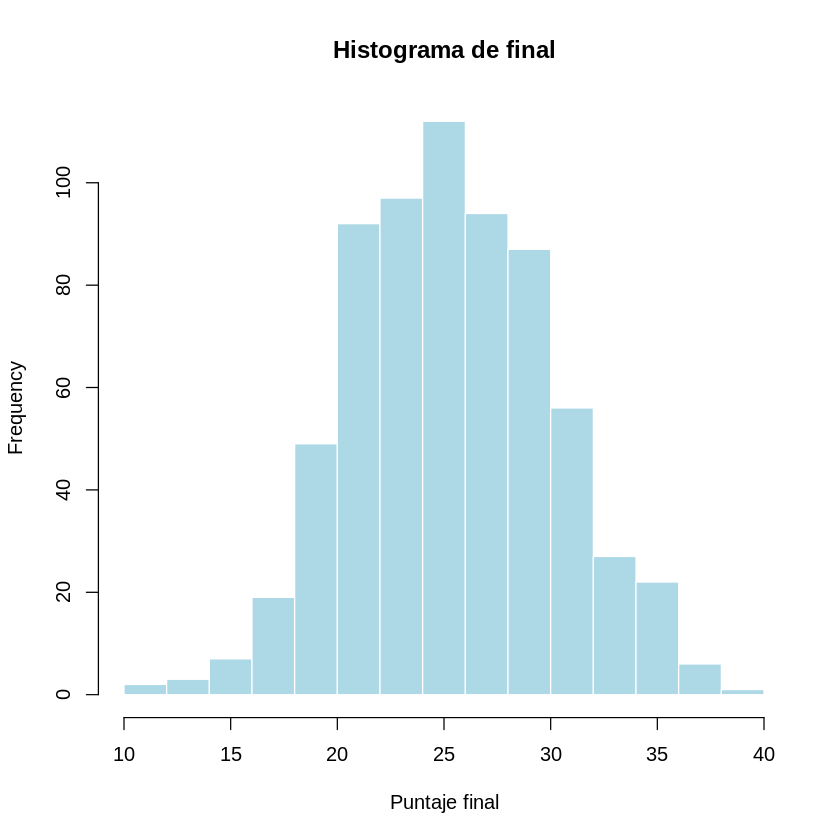

In [13]:
# Pregunta 2B.4: Extraer métricas de bondad de ajuste
hist(attend_sub$final,
     main = "Histograma de final",
     xlab = "Puntaje final",
     col = "lightblue",
     border = "white")

Genere diagrama de dispersión final

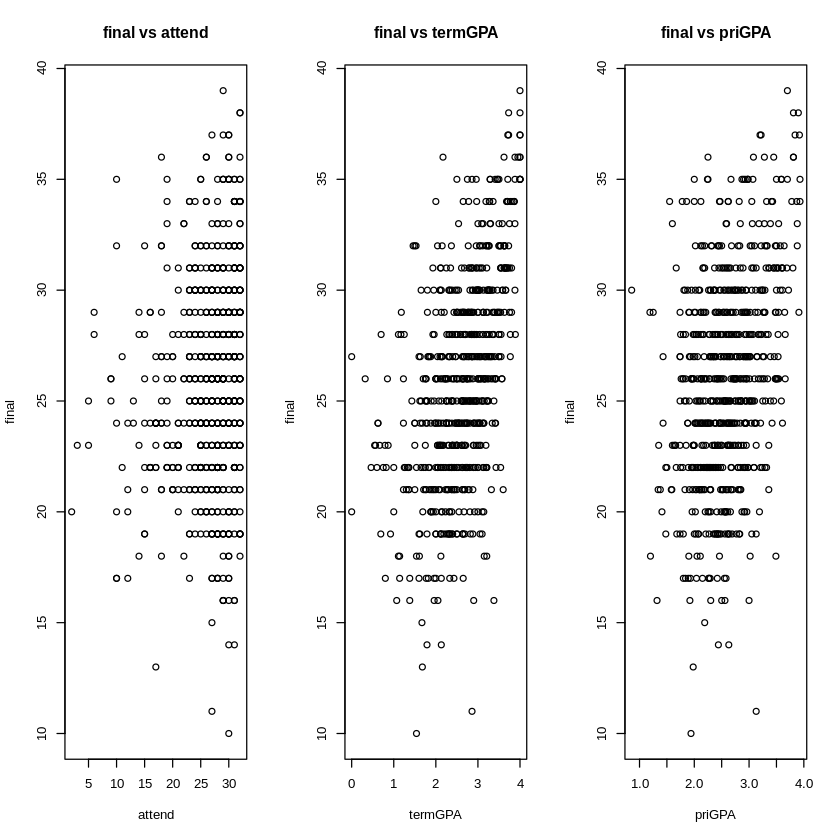

In [14]:
par(mfrow = c(1,3))

plot(attend_sub$attend, attend_sub$final,
     main = "final vs attend",
     xlab = "attend", ylab = "final")

plot(attend_sub$termGPA, attend_sub$final,
     main = "final vs termGPA",
     xlab = "termGPA", ylab = "final")

plot(attend_sub$priGPA, attend_sub$final,
     main = "final vs priGPA",
     xlab = "priGPA", ylab = "final")

par(mfrow = c(1,1))

Visualice la matriz de correlaciones con un mapa de calor

Loading required package: corrplot

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘corrplot’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

corrplot 0.95 loaded



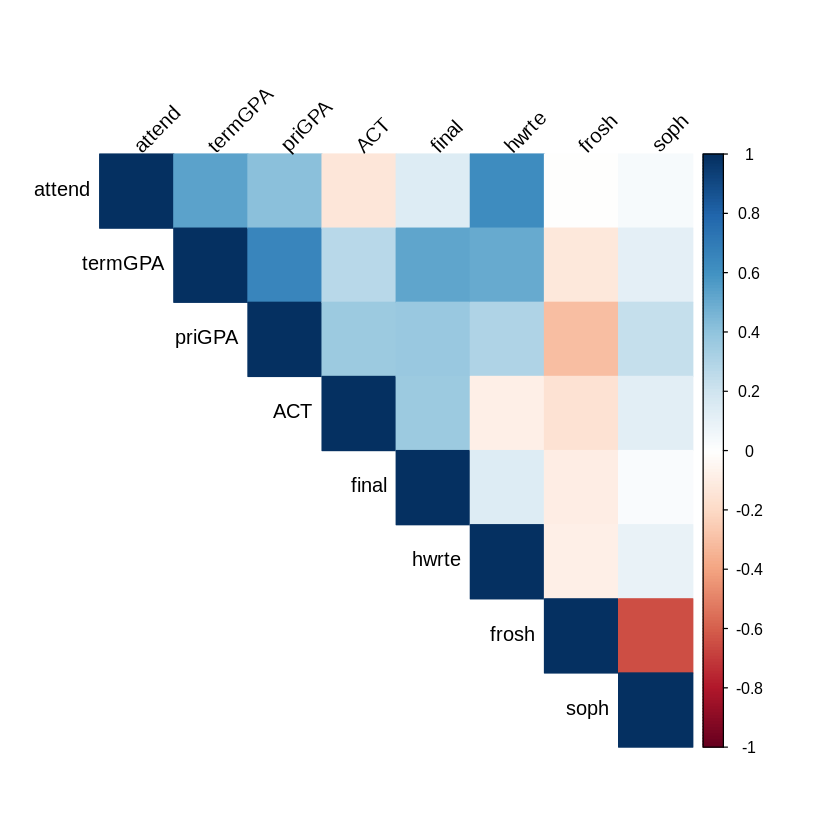

In [16]:
if (!require(corrplot)) install.packages("corrplot")
library(corrplot)

matriz_cor <- cor(attend_sub, use = "complete.obs")
corrplot(matriz_cor, method = "color", type = "upper", tl.col = "black", tl.srt = 45)

Genere un modelo de regresión lineal

In [17]:
modelo_attend <- lm(final ~ attend + termGPA + priGPA + ACT + hwrte + frosh + soph,
                    data = attend_sub)

summary(modelo_attend)


Call:
lm(formula = final ~ attend + termGPA + priGPA + ACT + hwrte + 
    frosh + soph, data = attend_sub)

Residuals:
     Min       1Q   Median       3Q      Max 
-15.9573  -2.5968  -0.0042   2.6582  11.0815 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 14.27176    1.45667   9.798  < 2e-16 ***
attend      -0.06956    0.04105  -1.694   0.0907 .  
termGPA      3.54151    0.31442  11.264  < 2e-16 ***
priGPA      -0.04149    0.40302  -0.103   0.9180    
ACT          0.27313    0.05031   5.429 7.94e-08 ***
hwrte       -0.01394    0.01043  -1.337   0.1817    
frosh       -0.61310    0.47672  -1.286   0.1989    
soph        -0.82251    0.39459  -2.084   0.0375 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.867 on 666 degrees of freedom
Multiple R-squared:  0.3373,	Adjusted R-squared:  0.3303 
F-statistic: 48.42 on 7 and 666 DF,  p-value: < 2.2e-16


### Pregunta 2B.5 — Modelo reducido (excluir variables no significativas) *(10 pts.)*

Interprete la bondad

In [ ]:
# Identificar variables significativas (p-value <= 0.05)

In [18]:
# Pregunta 2B.5: Modelo reducido (solo variables significativas)
# Variables significativas identificadas: termGPA, ACT, soph
# (ajuste según los resultados de su modelo)
modelo_attend <- lm(final ~ attend + termGPA + priGPA + ACT + hwrte + frosh + soph,
                    data = attend_sub)

summary(modelo_attend)


Call:
lm(formula = final ~ attend + termGPA + priGPA + ACT + hwrte + 
    frosh + soph, data = attend_sub)

Residuals:
     Min       1Q   Median       3Q      Max 
-15.9573  -2.5968  -0.0042   2.6582  11.0815 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 14.27176    1.45667   9.798  < 2e-16 ***
attend      -0.06956    0.04105  -1.694   0.0907 .  
termGPA      3.54151    0.31442  11.264  < 2e-16 ***
priGPA      -0.04149    0.40302  -0.103   0.9180    
ACT          0.27313    0.05031   5.429 7.94e-08 ***
hwrte       -0.01394    0.01043  -1.337   0.1817    
frosh       -0.61310    0.47672  -1.286   0.1989    
soph        -0.82251    0.39459  -2.084   0.0375 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.867 on 666 degrees of freedom
Multiple R-squared:  0.3373,	Adjusted R-squared:  0.3303 
F-statistic: 48.42 on 7 and 666 DF,  p-value: < 2.2e-16


### Pregunta 2B.6 — Comparación de modelos *(6 pts.)*

Compare el modelo completo y el modelo reducido en términos de **R² ajustado**.

In [ ]:
# Pregunta 2B.6: Comparación final de modelos

El  R² del modelo es aproximadamente 0.3373, lo que significa que alrededor del 33.73 % de la variación observada en final es explicada por las variables independientes incluidas en la regresión. El  R² ajustado es aproximadamente 0.3303, y corrige el R² penalizando la inclusión de variables adicionales. Como ambos valores son relativamente cercanos, no parece haber una pérdida importante por sobreajuste. En consecuencia, el modelo tiene una capacidad explicativa moderada.